In [1]:

import Pkg
Pkg.activate("/home/leonardo/datos/share_desktop/proyecto_julia/UNDCMotor_julia/julia_code/UNDCMotor")
using UNDCMotor


  Activating project at `~/datos/share_desktop/proyecto_julia/UNDCMotor_julia/julia_code/UNDCMotor`
[ Info: Precompiling UNDCMotor [e7a9ab87-c617-45b1-8476-4469afc7ea26] (cache misses: include_dependency fsize change (2), dep missing source (4))

SYSTEM: caught exception of type :MethodError while trying to print a failed Task notice; giving up


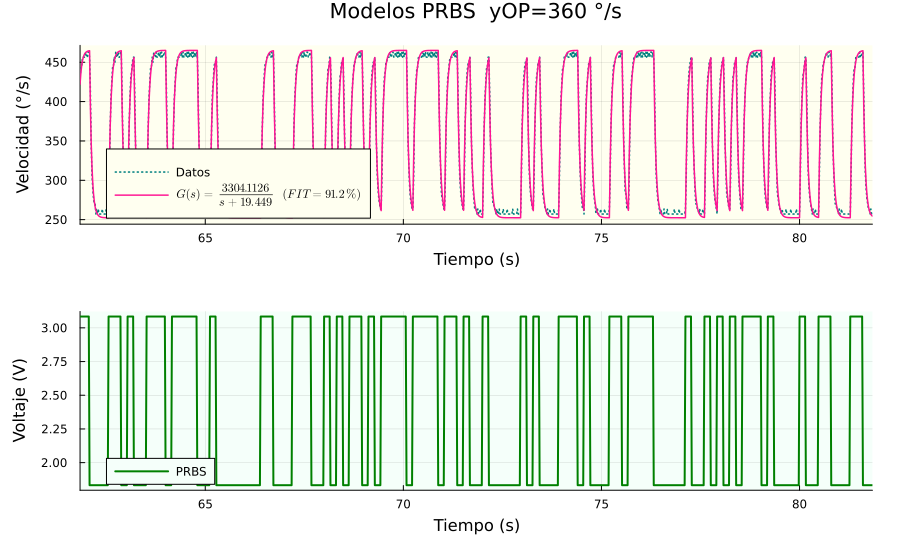

In [14]:
include("ControlUN.jl")


# definicion del sistema
sys = MotorSystem(port="/dev/ttyUSB0", bauds=460800);

s=tf("s")

# identificacion del sistema
G = get_model_prbs(sys; yop=360,sigma=100);

2903.1413

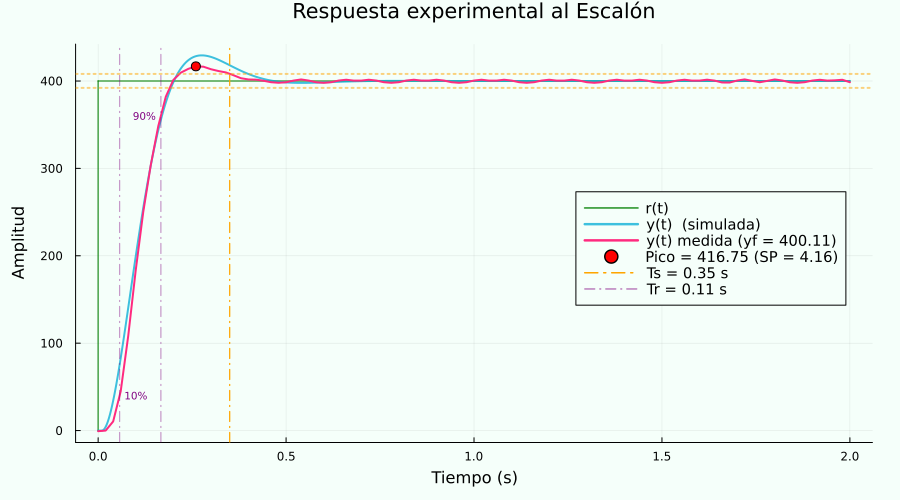

Info Resp. Escalón:
  Valor inicial:        0.000
  Valor final:        400.114
  Cambio escalón:     400.000
  Pico:               416.754
  Tiempo pico:          0.260 s
  Sobrepico:             4.16 %
  T. estabilización:    0.350 s
  T. subida:            0.110 s
  Max. |u(t)|:          2.886 V


In [28]:
G=transfer_function(sys, :speed)
a = denvec(G)[1][2]
b = numvec(G)[1][1]
ωn=15
ζ = 0.7
# calculo de las constantes
Kp = (2*ζ*ωn-a)/b
Ki = ωn^2/b


Gd=G*delay(0.01)
G1  = feedback(Gd,Kp)
T= feedback(G1*Ki/s,1)
set_pid(sys;  kp=Kp, ki=Ki, kd=0, beta=0, output=:speed, deadzone=0)
result = step_closed(sys; r0 = 0, r1 =400,  t0 = 0.5, t1 =2); 
stepinfo_exp(result;T=T)

In [16]:
print(entorno())

jupyter